---
title: "Lecture 25: MINRES, Conjugate gradients, Matrix-free iterations"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture25_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# MINRES and conjugate gradients

We have seen before that certain matrix properties enhance solutions to linear algebra problems. One of the most important of these is when $\mathbf{A}^T=\mathbf{A}$; i.e., $\mathbf{A}$ is symmetric. The Arnoldi iteration has a particularly useful specialization to this case. 

## Lanczos iteration

Starting from $\mathbf{A}\mathbf{Q}_m = \mathbf{Q}_{m+1} \mathbf{H}_m$, we left-multiply by $\mathbf{Q}_m^*$ to get

$$\mathbf{Q}_m^* \mathbf{A} \mathbf{Q}_m = \mathbf{Q}_m^* \mathbf{Q}_{m+1} \mathbf{H}_m = \tilde{\mathbf{H}}_m,$$

where $\tilde{\mathbf{H}}_m$ is rows 1 through $m$ of $\mathbf{H}_m$. 

. . .

If $\mathbf{A}$ is symmetric, then so is the left side of this equation, hence $\tilde{\mathbf{H}}_m$ is symmetric too. But it is also upper Hessenberg, meaning that the $(i,j)$ element is zero if $i > j+1$. By symmetry, this means that elements are zero when $j > i+1$ as well.

. . .

::: {.callout-warning icon=false}
## Fact: 
For a hermitian (or real symmetric) matrix, the upper Hessenberg matrix $\mathbf{H}_m$ produced by the Arnoldi iteration is tridiagonal.
:::

. . .

In general, a symmetric, upper Hessenberg matrix is tridiagonal!

. . .

<br>
The equation $\mathbf{A}\mathbf{q}_m = \mathbf{H}_{1m} \mathbf{q}_1 + \mathbf{H}_{2m} \mathbf{q}_2 + \cdots + \mathbf{H}_{m+1,m} \mathbf{q}_{m+1}$ shortens to $$\mathbf{A} \mathbf{q}_m = H_{m-1,m} \,\mathbf{q}_{m-1} + H_{mm} \,\mathbf{q}_m + H_{m+1,m}\,\mathbf{q}_{m+1}.$$

---

As before in deriving the Arnoldi iteration, when given the first $m$ vectors we can solve for the entries in column $m$ of $\mathbf{H}$ and then for $\mathbf{q}_{m+1}$. The resulting process is known as the **Lanczos iteration**. 

. . .

Its most important practical advantage is that while Arnoldi needs $O(m)$ steps to get $\mathbf{q}_{m+1}$ from the previous vectors, Lanczos needs only $O(1)$ steps, so restarting isn't required for symmetric matrices.

## MINRES

When $\mathbf{A}$ is symmetric and the Arnoldi iteration is reduced to Lanczos, the analog of GMRES is known as **MINRES**. Like GMRES, MINRES minimizes the residual $\|\mathbf{b}-\mathbf{A}\mathbf{x}\|$ over increasingly larger Krylov spaces.

. . .

MINRES is also more theoretically tractable than GMRES. Recall that the eigenvalues of a hermitian matrix are real. 

. . .

::: {.callout-warning icon=false}
## Theorem: Convergence of MINRES (indefinite case)
Suppose $\mathbf{A}$ is symmetric, invertible, and indefinite. Divide its eigenvalues into positive and negative sets $\Lambda_+$ and $\Lambda_-$, and define

$$
\kappa_+ = \frac{ \max_{\lambda \in \Lambda_+}  |\lambda| }{ \min_{\lambda \in \Lambda_+}  |\lambda| }, \qquad
\kappa_- = \frac{ \max_{\lambda \in \Lambda_-}  |\lambda| }{ \min_{\lambda \in \Lambda_-}  |\lambda| }.
$$

Then $\mathbf{x}_m$, the $m$th solution estimate of MINRES, satisfies

$$\frac{\|\mathbf{r}_m\|_2}{\|\mathbf{b}\|_2} \le  \left( \frac{\sqrt{\kappa_+\kappa_-} - 1}{\sqrt{\kappa_+\kappa_-} + 1} \right)^{\lfloor m/2\rfloor}.$$
:::

---

The bound for a definite matrix is better, as the next theorem shows. This upper bound on the residual obeys a linear convergence rate. As the product $\kappa_+\kappa_-$ grows, the rate of this convergence approaches 1. Hence the presence of eigenvalues close to the origin (relative to the max eigenvalues) is expected to force a slower convergence. 

. . .

Because the theorem gives an upper bound, MINRES may converge faster. All we can say is that the theorem guaranteed value is certain to be enough iterations.

---

In [10]:
# | echo: false
using LinearAlgebra
using FundamentalsNumericalComputation
using IterativeSolvers
using Plots

In [4]:
# the following matrix is indefinite
A = FNC.poisson(10) - 20I
λ = eigvals(Matrix(A))
isneg = @. λ < 0
@show sum(isneg),sum(.!isneg);

(sum(isneg), sum(.!(isneg))) = (13, 87)


. . .

In [5]:
# compute the relevant quantities from the theorem
mn,mx = extrema(-λ[isneg])
κ₋ = mx/mn
mn,mx = extrema(λ[.!isneg])
κ₊ = mx/mn
ρ = (sqrt(κ₋*κ₊)-1) / (sqrt(κ₋*κ₊)+1)

0.9026418585584018

. . .

Compare the behavior of MINRES to the upper bound given by the theorem.

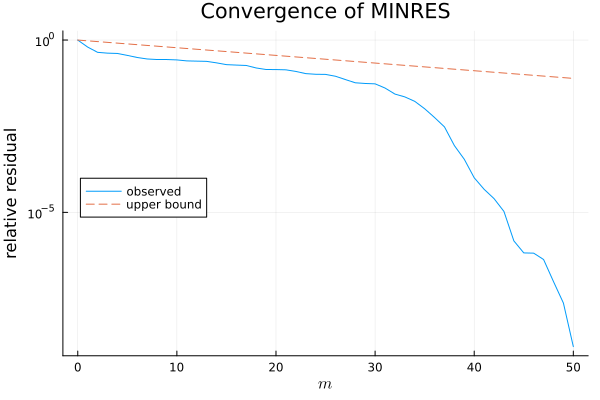

In [6]:
b = rand(100)
x,hist = minres(A,b,reltol=1e-10,maxiter=51,log=true);

relres = hist[:resnorm] / norm(b)
m = 0:length(relres)-1
plot(m,relres,label="observed",leg=:left,
	xaxis=L"m",yaxis=(:log10,"relative residual"),
	title=("Convergence of MINRES") )
plot!(m,ρ.^(m/2),l=:dash,label="upper bound")

## Conjugate gradients

Given positive definiteness in addition to symmetry, we arrive at perhaps the most famous Krylov subspace method for $\mathbf{A}\mathbf{x}=\mathbf{b}$, called **conjugate gradients**. 

. . .

Suppose now that $\mathbf{A}$ is symmetric and positive definite (SPD). Then $\mathbf{A}$ has a Cholesky factorization, $\mathbf{A}=\mathbf{R}^\top\mathbf{R}$. Therefore, for any vector $\mathbf{u}$,

$$
\mathbf{u}^*\mathbf{A}\mathbf{u} = (\mathbf{R}\mathbf{u})^*(\mathbf{R}\mathbf{u})=\|\mathbf{R} \mathbf{u}\|^2,
$$

which is nonnegative and zero only when $\mathbf{u}=\boldsymbol{0}$, provided $\mathbf{A}$ (and therefore $\mathbf{R}$) is nonsingular. 

. . .

Hence we can define a special vector norm relative to $\mathbf{A}$:

$$\| \mathbf{u} \|_{\mathbf{A}} = \left( \mathbf{u}^*\mathbf{A}\mathbf{u} \right)^{1/2}.$$

. . .

::: {.callout-note icon=false}
## Definition: Method of conjugate gradients (CG)
For each $m=1,2,3,\ldots$, minimize $\|\mathbf{x}_m-\mathbf{x}\|_{\mathbf{A}}$ for $\mathbf{x}$ in the Krylov subspace $\mathcal{K}_m$.
:::

## Convergence

The convergence of CG and MINRES is dependent on the eigenvalues of $\mathbf{A}$. In the SPD case the eigenvalues are real and positive, and they equal the singular values. Hence the condition number $\kappa$ is equal to the ratio of the largest eigenvalue to the smallest one. The following theorem suggests that MINRES and CG are not so different in convergence.

. . .

::: {.callout-warning icon=false}
## Theorem: MINRES and CG convergence (definite case)
Let $\mathbf{A}$ be real and SPD with 2-norm condition number $\kappa$. For MINRES define $R(m)=\|\mathbf{r}_m\|_2/\|\mathbf{b}\|_2$, and for CG define $R(m)=\|\mathbf{x}_m-\mathbf{x}\|_{\mathbf{A}}/\|\mathbf{x}\|_{\mathbf{A}}$,
where $\mathbf{r}_m$ and $\mathbf{x}_m$ are the residual and solution approximation associated with the space $\mathcal{K}_m$. Then

$$R(m) \le  2\, \left( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^m.$$
:::

. . .

This theorem characterizes the convergence of MINRES and CG similarly, differing only in whether the measurement is of the residual or the $\mathbf{A}$-norm of the error, respectively. While these are different quantities, in practice one may not find a consistent advantage for one method over the other.

---

Specifically, to make the bound in this theorem less than a number $\epsilon$ requires

\begin{gather*}
  2 \left( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)^m \approx \epsilon, \\
  m \log \left( \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1} \right)
  \approx \log\Bigl( \frac{\epsilon}{2} \Bigr).
\end{gather*}

. . .

We estimate

\begin{align*}
   \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}
 &=  (1 - \kappa^{-1/2}\,) (1 + \kappa^{-1/2}\,)^{-1}\\
 &= (1 - \kappa^{-1/2}\,)  (1 - \kappa^{-1/2} + \kappa^{-1} + \cdots)\\
 &= 1 - 2\kappa^{-1/2} + O(\kappa^{-1}) \quad \text{ as $\kappa
   \rightarrow \infty$.}
\end{align*}

. . .

With the Taylor expansion $\log(1+x) = x - (x^2/2) + \cdots$, we finally conclude

\begin{gather*}
  2 m \kappa^{-1/2} \approx \log\Bigl( \frac{\epsilon}{2} \Bigr),
  \text{ or }
  m = O(\sqrt{\kappa}),
\end{gather*}

as an estimate of the number of iterations needed to achieve a fixed accuracy.

---

::: {.callout-warning icon=false}
## Fact: 
As a rule of thumb, the number of iterations required for MINRES or CG to converge is $O(\sqrt{\kappa})$, where $\kappa$ is the condition number.
:::

. . .

This estimate fails for very large $\kappa$, however.

. . .

We will compare MINRES and CG on some quasi-random SPD problems.

. . .

In [7]:
# the first matrix has a condition number of 100
n = 5000
density = 0.001
A = FNC.sprandsym(n,density,1/100)
x = (1:n)/n
b = A*x;

---

minres error: 1.204e-5
cg error: 5.086e-6


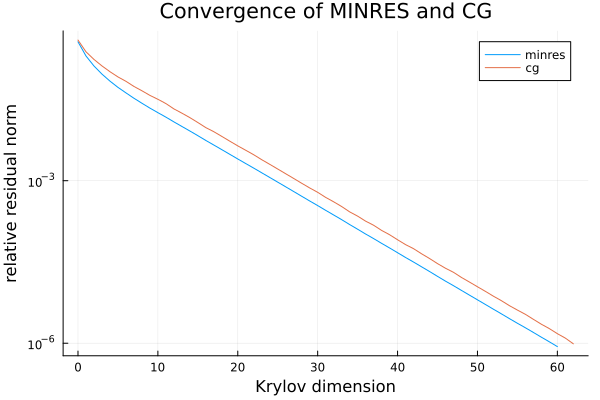

In [11]:
plt = plot(title="Convergence of MINRES and CG",
    xaxis=("Krylov dimension"),yaxis=(:log10,"relative residual norm"))
for method in [minres,cg]
    x̃,history = method(A,b,reltol=1e-6,maxiter=1000,log=true);
    relres = history[:resnorm] / norm(b)
    plot!(0:length(relres)-1,relres,label="$method")
    err = round( norm( x̃ - x ) / norm(x), sigdigits=4 )
    println("$method error: $err")
end
plt

. . .

There is little difference between the two methods here. 

---

Next, we increase the condition number of the matrix by a factor of 25. The rule of thumb predicts that the number of iterations required should increase by a factor of about 5.

In [12]:
A = FNC.sprandsym(n,density,1/2500)
b = A*x;

minres error: 0.0002572
cg error: 4.226e-5


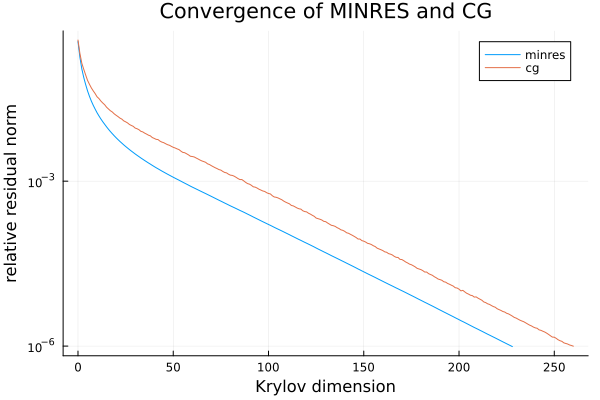

In [13]:
plt = plot(title="Convergence of MINRES and CG",
    xaxis=("Krylov dimension"),yaxis=(:log10,"relative residual norm"))
for method in [minres,cg]
    x̃,history = method(A,b,reltol=1e-6,maxiter=1000,log=true);
    relres = history[:resnorm] / norm(b)
    plot!(0:length(relres)-1,relres,label="$method")
    err = round( norm( x̃ - x ) / norm(x), sigdigits=4 )
    println("$method error: $err")
end
plt

[Both methods have an early superlinear phase that allow them to finish slightly sooner than the factor of 5 predicted: the theorem is an upper bound, not necessarily an approximation. Both methods ultimately achieve the same reduction in the residual; MINRES stops earlier, but with a slightly larger error.]{.content-hidden when-format='revealjs' when-format='pptx'} 

# Matrix-free iterations

A primary reason for our interest in matrices is their relationship to linear transformations. 

. . .

Recall that *every* linear transformation between finite-dimensional vector spaces can be represented as a matrix-vector multiplication.

## Matrix-free iterations

Recall that with the fixed-point iterative method, we solved the nonlinear rootfinding problem $\mathbf{f}(\mathbf{x})=\boldsymbol{0}$ with methods that needed only the ability to evaluate $\mathbf{f}$ at any known value of $\mathbf{x}$. By repeatedly evaluating $\mathbf{f}$ at cleverly chosen points, these algorithms were able to return an estimate for $\mathbf{f}^{-1}(\boldsymbol{0})$.

. . .

A close examination reveals that the power method and Krylov subspace methods have the same structure because the only appearance of the matrix $\mathbf{A}$ in them is to multiply a known vector, i.e., to evaluate $\mathbf{f}(\mathbf{x})=\mathbf{A}\mathbf{x}$. This is used to evaluate the inverse, $\mathbf{A}^{-1}\mathbf{b}$. 

. . .

Bringing these points of view together leads us to a cornerstone of modern scientific computation: *matrix-free iterations*. Krylov subspace methods can be used to invert a linear transformation if one provides code for the transformation, even if its associated matrix is not known explicitly. 

## Blurring images

Previously we saw that a grayscale image can be represented as an $m\times n$ matrix $\mathbf{X}$ of pixel intensity values. Now consider a simple model for blurring the image. Define $\mathbf{B}_m$ as the $m\times m$ tridiagonal matrix

$$(\mathbf{B}_m)_{ij} =
\begin{cases}
\tfrac{1}{2} & \text{if $i=j$},\\
\tfrac{1}{4} & \text{if $|i-j|=1$},\\
0 & \text{otherwise.}
\end{cases}$$

. . .

The product $\mathbf{B}_m\mathbf{X}$ applies $\mathbf{B}_m$ to each column of $\mathbf{X}$. Within that column it does a weighted average of the values of each pixel and its two neighbors. That has the effect of blurring the image vertically. We can increase the amount of blur by applying $\mathbf{B}_m$ repeatedly.

. . .

To blur the image horizontally, we can apply $\mathbf{B}_n$ to each row of $\mathbf{X}$. The product $\mathbf{X}\mathbf{B}_n$ applies $\mathbf{B}_n$ to each row of $\mathbf{X}$, and has the effect of blurring the image horizontally.

---

 So we can describe blur in both directions as the function

$$\operatorname{blur}(\mathbf{X}) = \mathbf{B}_m^k \mathbf{X} \mathbf{B}^k_n$$

for a positive integer $k$.

. . .

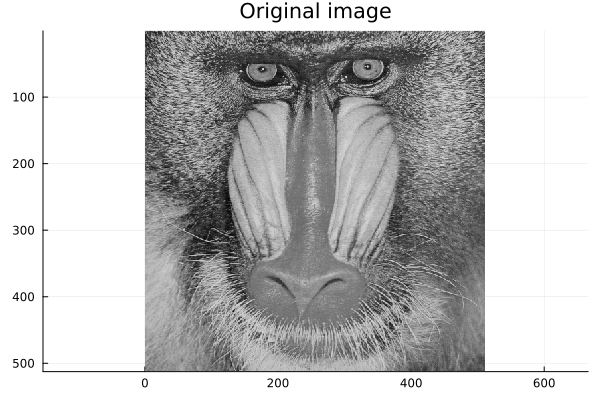

In [14]:
img = testimage("mandrill")
m,n = size(img)
X = @. Float64(Gray(img))
plot(Gray.(X),title="Original image",aspect_ratio=1)

---

In [15]:
# define the one-dimensional tridiagonal blurring matrices
function blurmatrix(d)
    v1 = fill(0.25,d-1)
    return spdiagm(0=>fill(0.5,d), 1=>v1, -1=>v1)
end
Bm,Bn = blurmatrix(m),blurmatrix(n);

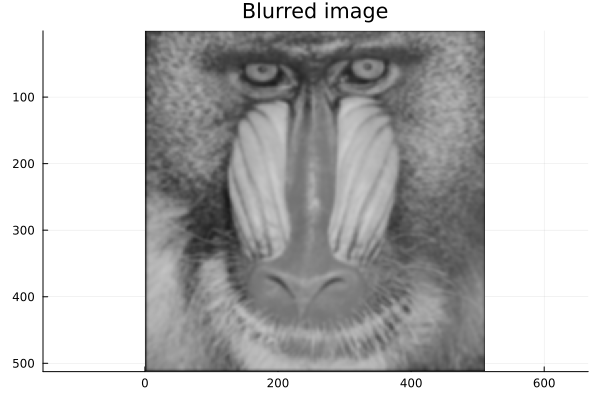

In [16]:
# the results of using $k=12$ repetitions of the blur in each direction
blur = X -> Bm^12 * X * Bn^12;
Z = blur(X)
plot(Gray.(Z),title="Blurred image")

## Deblurring

A more interesting operation is *deblurring*: given an image blurred by poor focus, can we reconstruct the true image? Conceptually, we want to invert the function $\operatorname{blur}(\mathbf{X})$.

. . .

It's easy to see from the definition of this function that the blur operation is a linear transformation on image matrices. But an $m\times n$ image matrix is equivalent to a length-$mn$ vector—it's just a matter of interpreting the shape of the same data. Let $\operatorname{vec}(\mathbf{X})=\mathbf{x}$ and $\operatorname{unvec}(\mathbf{x})=\mathbf{X}$ be the mathematical statements of such reshaping operations. Now say $\mathbf{X}$ is the original image and $\mathbf{Z}=\operatorname{blur}(\mathbf{X})$ is the blurred one. 

. . .

Then by linearity there is some matrix $\mathbf{A}$ such that

$$\mathbf{A} \operatorname{vec}(\mathbf{X}) = \operatorname{vec}(\mathbf{Z}),$$

or $\mathbf{A}\mathbf{x}=\mathbf{z}$.

. . .

The matrix $\mathbf{A}$ is $mn\times mn$; for a 12-megapixel image, it would have $1.4\times 10^{14}$ entries! Admittedly, it is extremely sparse, but the point is that we don't need it at all. 

---

Instead, given any vector $\mathbf{u}$ we can compute $\mathbf{v}=\mathbf{A}\mathbf{u}$ through the steps

\begin{align*}
  \mathbf{U} &= \operatorname{unvec}(\mathbf{u}),\\
  \mathbf{V} &= \operatorname{blur}(\mathbf{U}),\\
  \mathbf{v} &= \operatorname{vec}(\mathbf{V}).
\end{align*}

. . .

The following example shows how to put these ideas into practice with MINRES.

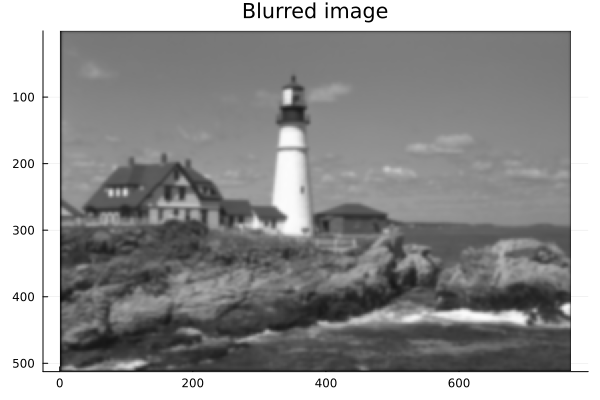

In [17]:
# repeat the earlier process to blur an original image X to get Z
img = testimage("lighthouse")
m,n = size(img)
X = @. Float64(Gray(img))

B = spdiagm(0=>fill(0.5,m),
        1=>fill(0.25,m-1),-1=>fill(0.25,m-1))
C = spdiagm(0=>fill(0.5,n),
        1=>fill(0.25,n-1),-1=>fill(0.25,n-1))
blur = X -> B^12 * X * C^12
Z = blur(X)
plot(Gray.(Z),title="Blurred image")

---

Now imagine that $\mathbf{X}$ is unknown and that we want to recover it from $\mathbf{Z}$.

In [18]:
# vec (built-in) converts matrix to vector
unvec = z -> reshape(z,m,n);  # convert vector to matrix

In [19]:
T = LinearMap(x -> vec(blur(unvec(x))),m*n);

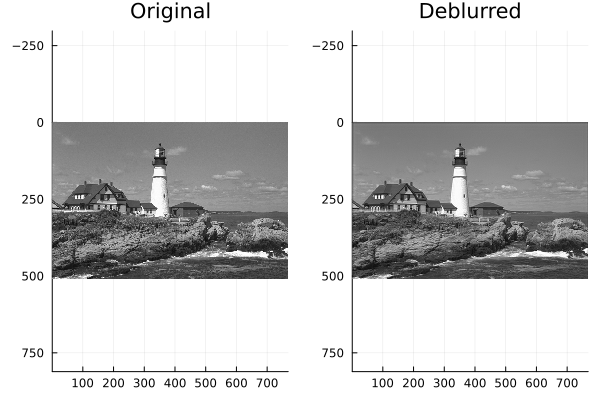

In [ ]:
y = minres(T,vec(Z),maxiter=50,reltol=1e-5);
# function clamp01 in Images restricts values to be in the interval [0,1]
Y = unvec( clamp01.(y) )

plot(Gray.(X),layout=2,title="Original")
plot!(Gray.(Y),subplot=2,title="Deblurred")

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->